In [1]:
print("hello")

hello


In [2]:
import pandas as pd
df=pd.read_csv('kenya_census_2019.csv')
df.head()

,County,Male,Female,Population_2019,Land_Area_SqKm,Population_Density
0,Mombasa,610257,598046,1208333,219.9,5495
1,Kwale,425121,441681,866820,8267.1,105
2,Kilifi,704089,749673,1453787,12539.7,116
3,Tana River,158550,157391,315943,37950.5,8
4,Lamu,76103,67813,143920,6253.3,23


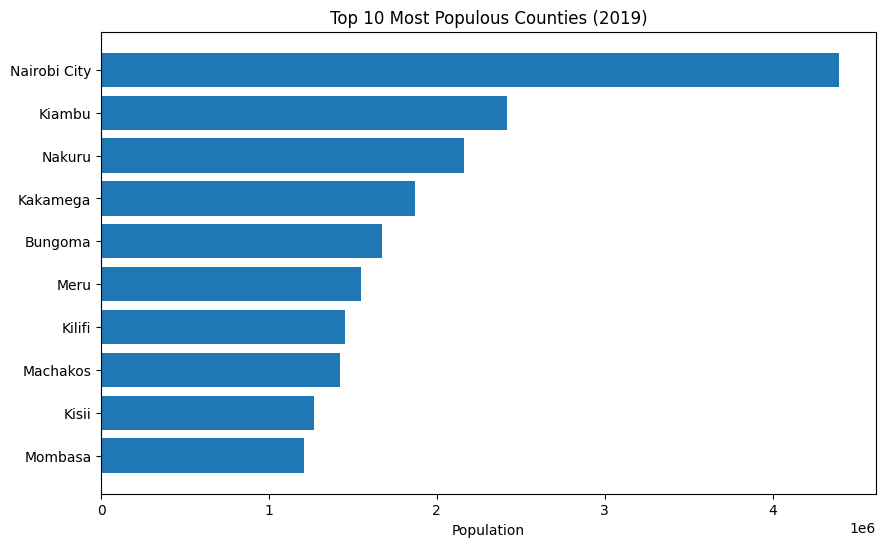

In [3]:
import matplotlib.pyplot as plt

# Sort by population, get top 10
top10 = df.sort_values('Population_2019', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['County'], top10['Population_2019'])
plt.xlabel('Population')
plt.title('Top 10 Most Populous Counties (2019)')
plt.gca().invert_yaxis()  # biggest bar on top
plt.show()

In [9]:
plt.savefig('chart_name.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

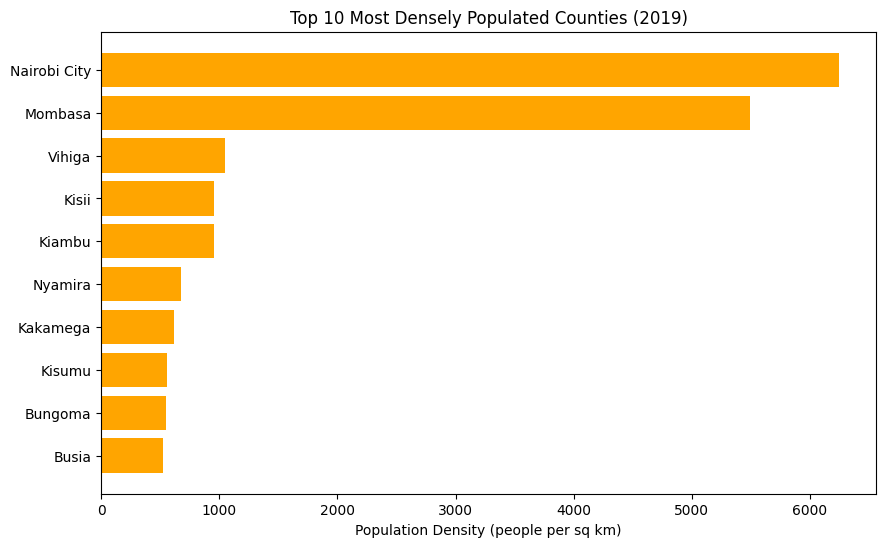

In [4]:
top10_density = df.sort_values('Population_Density', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10_density['County'], top10_density['Population_Density'], color='orange')
plt.xlabel('Population Density (people per sq km)')
plt.title('Top 10 Most Densely Populated Counties (2019)')
plt.gca().invert_yaxis()
plt.show()

In [8]:
plt.savefig('chart_name.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [5]:
growth_rate = 0.022  # 2.2% per year, from KNBS inter-censal growth rate
years_ahead = 2029 - 2019  # = 10

df['Predicted_2029'] = df['Population_2019'] * (1 + growth_rate) ** years_ahead

# View the result, sorted by predicted population
df[['County', 'Population_2019', 'Predicted_2029']].sort_values('Predicted_2029', ascending=False).head(10)

,County,Population_2019,Predicted_2029
46,Nairobi City,4397073,5.466038e+06
21,Kiambu,2417735,3.005506e+06
31,Nakuru,2162202,2.687851e+06
36,Kakamega,1867579,2.321603e+06
38,Bungoma,1670570,2.076699e+06
11,Meru,1545714,1.921490e+06
2,Kilifi,1453787,1.807215e+06
15,Machakos,1421932,1.767615e+06
44,Kisii,1266860,1.574844e+06
0,Mombasa,1208333,1.502089e+06


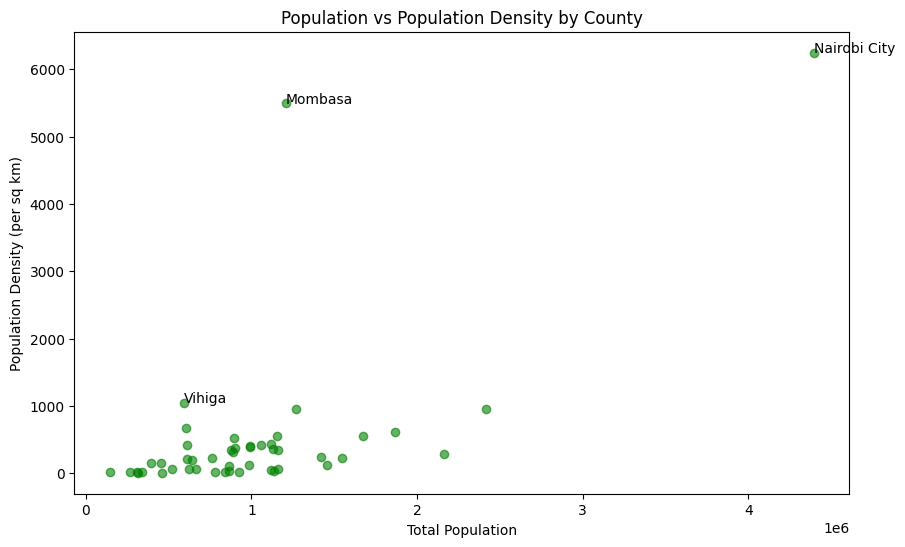

In [6]:
plt.figure(figsize=(10,6))
plt.scatter(df['Population_2019'], df['Population_Density'], color='green', alpha=0.6)
plt.xlabel('Total Population')
plt.ylabel('Population Density (per sq km)')
plt.title('Population vs Population Density by County')

# Optional: label a few interesting points
for i in range(len(df)):
    if df['Population_Density'].iloc[i] > 1000:  # only label very dense counties
        plt.annotate(df['County'].iloc[i], (df['Population_2019'].iloc[i], df['Population_Density'].iloc[i]))

plt.show()

In [7]:
plt.savefig('chart_name.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>